# 05 — Explicabilité SHAP
**Objectif :** expliquer *pourquoi* le modèle prédit un défaut, au niveau global et individuel.

**SHAP (SHapley Additive exPlanations)** décompose chaque prédiction en contributions additives par feature, fondées sur la théorie des jeux. Pour un prêt donné :

$$ \text{prédiction} = \text{valeur de base} + \sum_i \phi_i $$

où $\phi_i$ est la contribution de la feature $i$.

**Pourquoi c'est central en credit risk :** un régulateur (et le client) exige de savoir pourquoi un prêt est refusé. SHAP fournit cette traçabilité, exigée par le RGPD (droit à l'explication) et les guidelines EBA.

**Sortie :** explainer SHAP + valeurs sauvegardées pour l'app Streamlit.

In [1]:
import os
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import xgboost as xgb

plt.rcParams['figure.figsize'] = (10, 6)

DATA_DIR = os.path.join('..', 'data')
MODELS_DIR = os.path.join('..', 'models')

# Modèle XGBoost entraîné au notebook 04
xgb_model = xgb.XGBClassifier()
xgb_model.load_model(os.path.join(MODELS_DIR, 'xgb_credit_risk.json'))

X_test = pd.read_parquet(os.path.join(DATA_DIR, 'X_test.parquet'))
y_test = pd.read_parquet(os.path.join(DATA_DIR, 'y_test.parquet'))['default']

with open(os.path.join(MODELS_DIR, 'metadata.pkl'), 'rb') as f:
    metadata = pickle.load(f)

print(f"Modèle chargé. AUC test = {metadata['auc_xgb']:.4f}")
print(f"X_test : {X_test.shape}")

Modèle chargé. AUC test = 0.7351
X_test : (20000, 39)


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Calcul des valeurs SHAP

`TreeExplainer` est exact et rapide pour les modèles à base d'arbres (XGBoost).
On l'applique sur un échantillon de 2000 prêts du test (suffisant pour les analyses globales, plus rapide que les 20K).

In [2]:
explainer = shap.TreeExplainer(xgb_model)

# Échantillon pour les plots globaux
X_sample = X_test.sample(n=2000, random_state=42)
shap_values = explainer(X_sample)

print(f"SHAP values calculées : {shap_values.values.shape}")
print(f"Valeur de base (log-odds) : {shap_values.base_values[0]:.4f}")

SHAP values calculées : (2000, 39)
Valeur de base (log-odds) : -2.8434


## 2. Importance globale — Beeswarm

Chaque point = un prêt. Position horizontale = impact sur la prédiction.
Couleur = valeur de la feature (rouge = haute, bleu = basse).

Lecture : pour une feature donnée, si les points rouges sont à droite → *valeur haute pousse vers le défaut*.

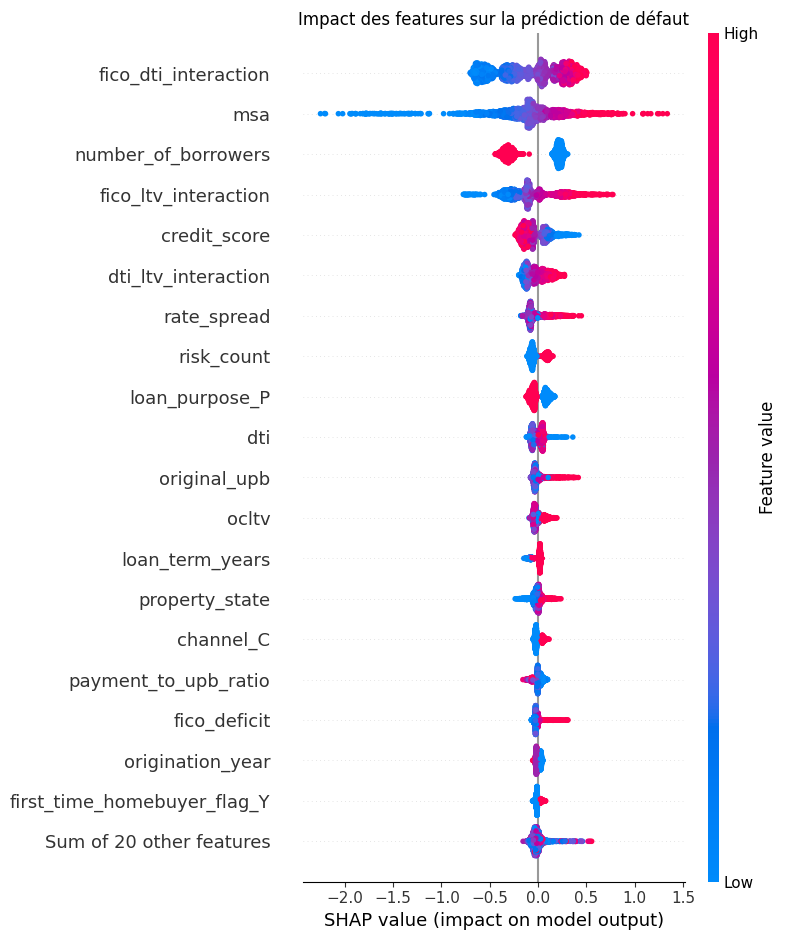

In [3]:
shap.plots.beeswarm(shap_values, max_display=20, show=False)
plt.title('Impact des features sur la prédiction de défaut')
plt.tight_layout()
plt.show()

## 3. Importance globale — Bar (moyenne des |SHAP|)

Classement des features par contribution moyenne absolue. Plus robuste que l'importance native XGBoost.

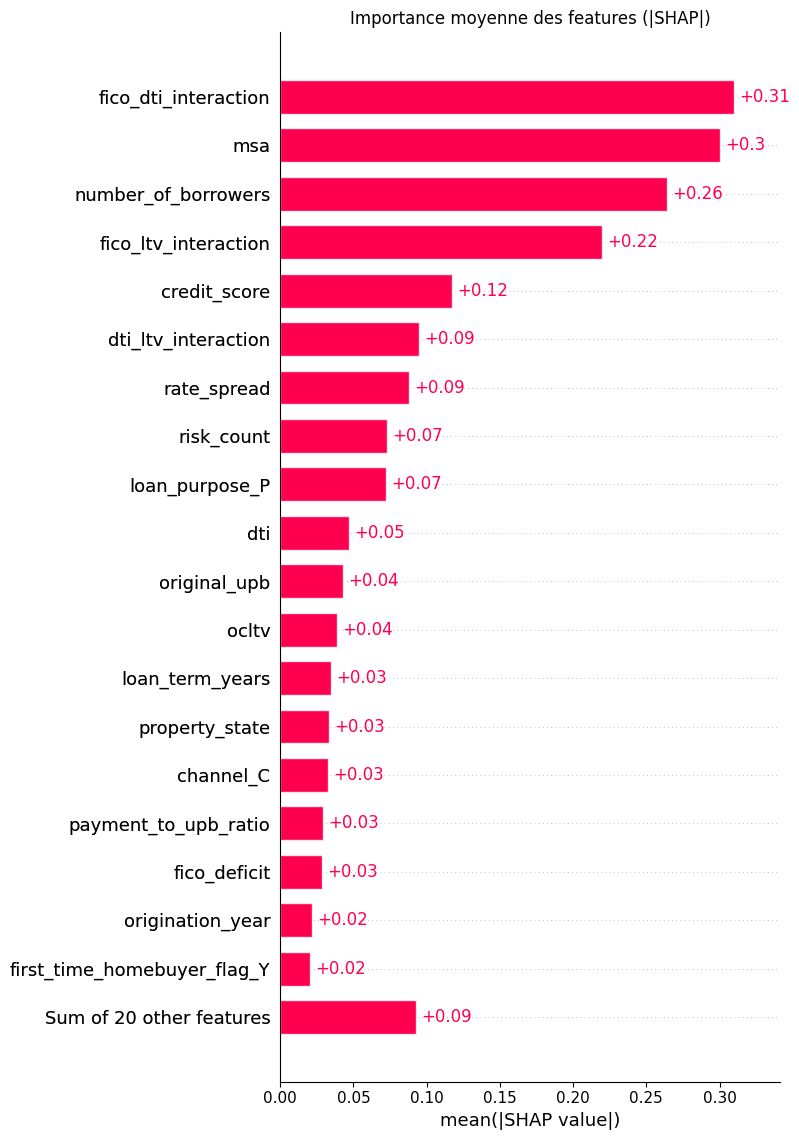


Top 15 features :
             feature  mean_abs_shap
fico_dti_interaction       0.309538
                 msa       0.300383
 number_of_borrowers       0.264278
fico_ltv_interaction       0.219609
        credit_score       0.117244
 dti_ltv_interaction       0.094759
         rate_spread       0.087771
          risk_count       0.072775
      loan_purpose_P       0.071997
                 dti       0.046851
        original_upb       0.043004
               ocltv       0.038936
     loan_term_years       0.034826
      property_state       0.033523
           channel_C       0.032796


In [4]:
shap.plots.bar(shap_values, max_display=20, show=False)
plt.title('Importance moyenne des features (|SHAP|)')
plt.tight_layout()
plt.show()

# Version tabulaire
mean_abs_shap = pd.DataFrame({
    'feature': X_sample.columns,
    'mean_abs_shap': np.abs(shap_values.values).mean(axis=0),
}).sort_values('mean_abs_shap', ascending=False)
print("\nTop 15 features :")
print(mean_abs_shap.head(15).to_string(index=False))

## 4. Dependence plots — relation feature → risque

Montre comment la contribution SHAP d'une feature varie selon sa valeur.
Révèle les seuils et non-linéarités.

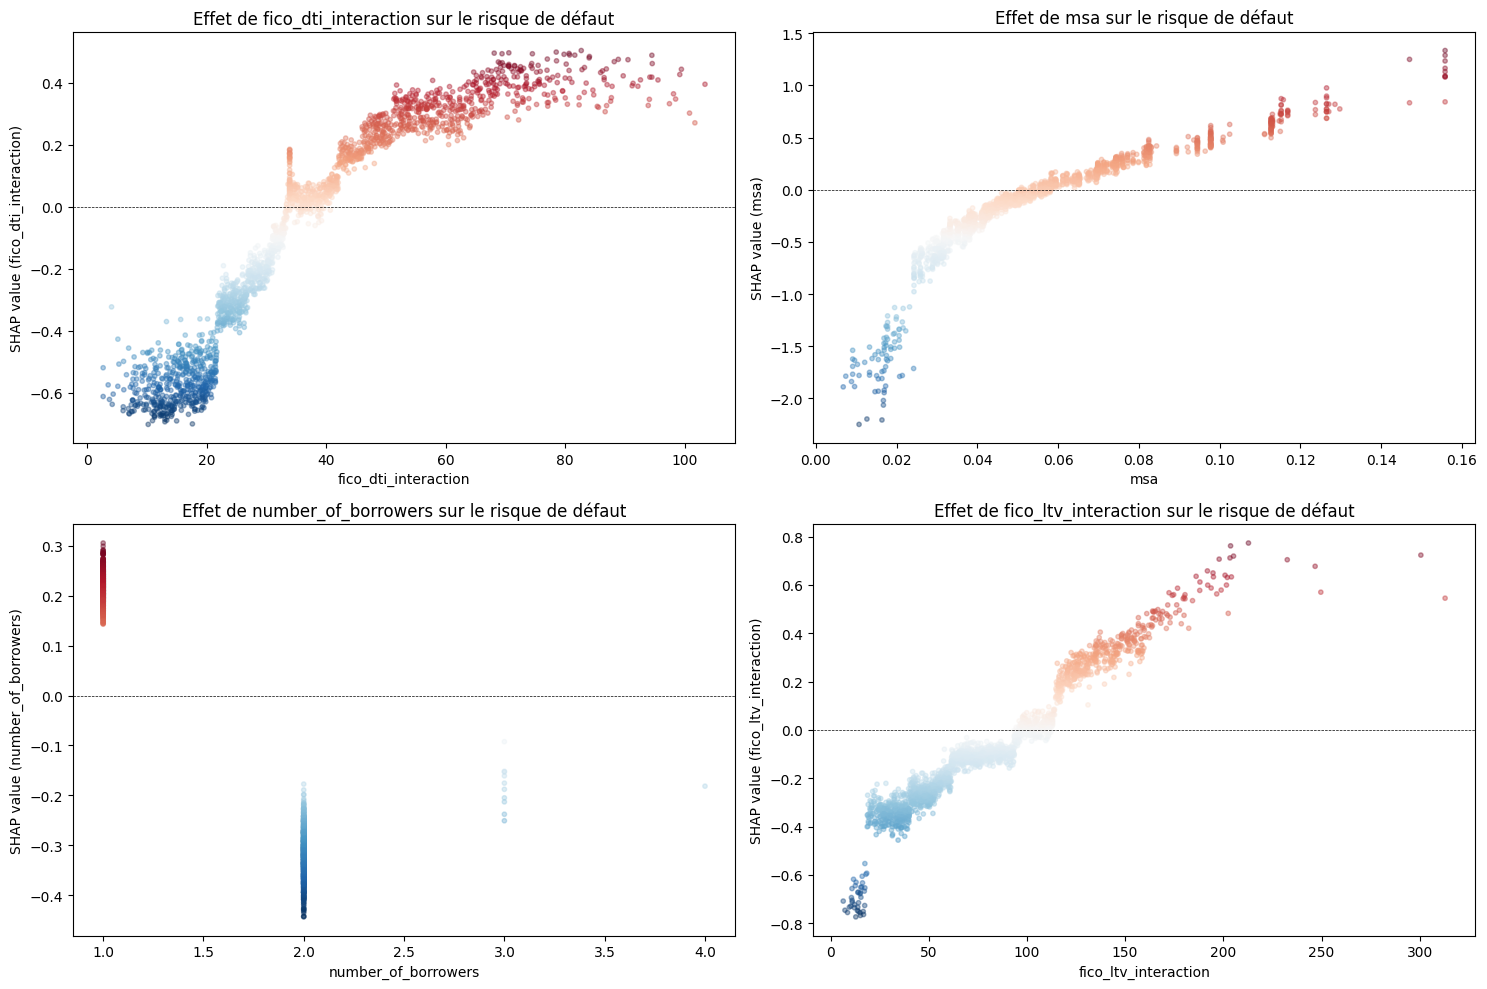

In [5]:
top_features = mean_abs_shap.head(4)['feature'].tolist()

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
for ax, feat in zip(axes.flat, top_features):
    idx = list(X_sample.columns).index(feat)
    ax.scatter(X_sample[feat], shap_values.values[:, idx],
               s=10, alpha=0.4, c=shap_values.values[:, idx], cmap='RdBu_r')
    ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
    ax.set_xlabel(feat)
    ax.set_ylabel(f'SHAP value ({feat})')
    ax.set_title(f'Effet de {feat} sur le risque de défaut')
plt.tight_layout()
plt.show()

## 5. Explication individuelle — Waterfall

Pour un prêt donné, décompose la prédiction : on part de la valeur de base (log-odds moyen)
et chaque feature pousse vers le haut (risque) ou le bas (sécurité).

Prêt analysé (index échantillon 1617)
Probabilité de défaut prédite : 61.57%

Profil du prêt :
  credit_score: 660.0
  dti: 42.0
  ocltv: 95.0
  original_upb: 133000.0
  risk_count: 0.0


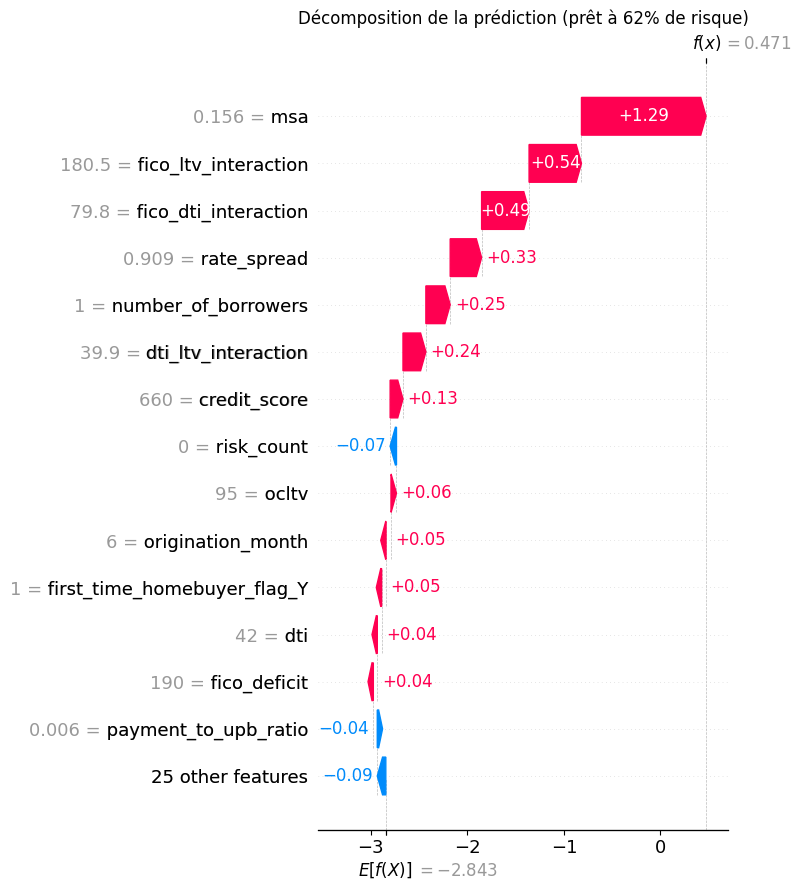

In [6]:
# On prend un prêt à haut risque prédit pour illustrer
proba_sample = xgb_model.predict_proba(X_sample)[:, 1]
high_risk_idx = np.argmax(proba_sample)

print(f"Prêt analysé (index échantillon {high_risk_idx})")
print(f"Probabilité de défaut prédite : {proba_sample[high_risk_idx]:.2%}")
print(f"\nProfil du prêt :")
profile = X_sample.iloc[high_risk_idx]
for col in ['credit_score', 'dti', 'ocltv', 'original_upb', 'risk_count']:
    if col in profile.index:
        print(f"  {col}: {profile[col]:.1f}")

shap.plots.waterfall(shap_values[high_risk_idx], max_display=15, show=False)
plt.title(f'Décomposition de la prédiction (prêt à {proba_sample[high_risk_idx]:.0%} de risque)')
plt.tight_layout()
plt.show()

## 6. Comparaison : prêt sûr vs prêt risqué

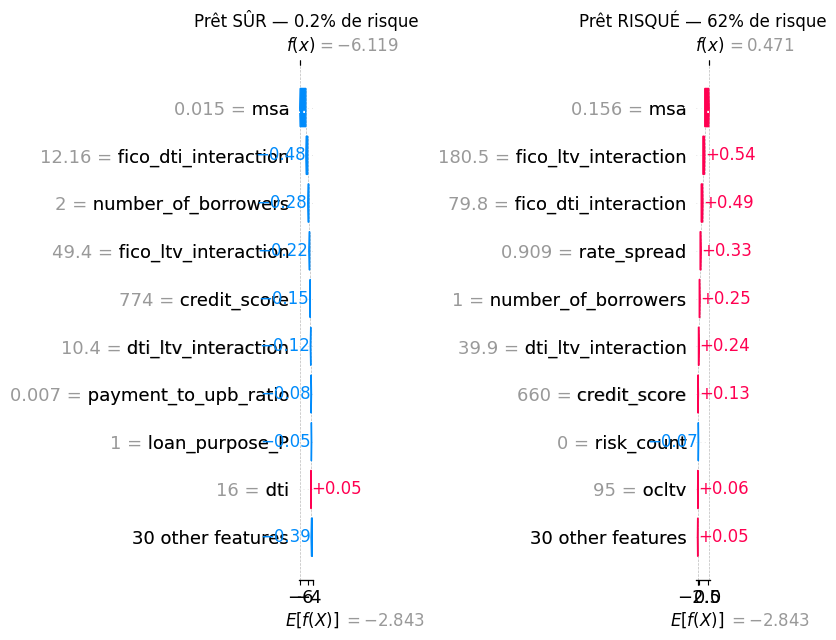

In [9]:
low_risk_idx = np.argmin(proba_sample)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

plt.sca(axes[0])
shap.plots.waterfall(shap_values[low_risk_idx], max_display=10, show=False)
axes[0].set_title(f'Prêt SÛR — {proba_sample[low_risk_idx]:.1%} de risque')

plt.sca(axes[1])
shap.plots.waterfall(shap_values[high_risk_idx], max_display=10, show=False)
axes[1].set_title(f'Prêt RISQUÉ — {proba_sample[high_risk_idx]:.0%} de risque')

plt.tight_layout()
plt.show()

## 7. Sauvegarde de l'explainer pour Streamlit

L'app aura besoin de l'explainer pour générer des explications en temps réel sur de nouveaux profils.

In [8]:
with open(os.path.join(MODELS_DIR, 'shap_explainer.pkl'), 'wb') as f:
    pickle.dump(explainer, f)

# On sauvegarde aussi le classement d'importance pour le RAG (notebook 06)
mean_abs_shap.to_parquet(os.path.join(DATA_DIR, 'shap_importance.parquet'), index=False)

print("Sauvegardé :")
print(f"  models/shap_explainer.pkl")
print(f"  data/shap_importance.parquet")
print(f"\nTop 5 drivers du risque de défaut :")
for _, row in mean_abs_shap.head(5).iterrows():
    print(f"  {row['feature']}: {row['mean_abs_shap']:.4f}")

Sauvegardé :
  models/shap_explainer.pkl
  data/shap_importance.parquet

Top 5 drivers du risque de défaut :
  fico_dti_interaction: 0.3095
  msa: 0.3004
  number_of_borrowers: 0.2643
  fico_ltv_interaction: 0.2196
  credit_score: 0.1172
